# Notebook de obtención, limpieza y transformación de datos — Fase 2

**Proyecto:** Uso de redes sociales y salud mental autopercibida en estudiantes de enseñanza media (YRBS 2023)
**Asignatura:** MCDI500 · Programación para la Ciencia de Datos · **Grupo 8**
**Repositorio:** https://github.com/MatiasManriquezO/proyecto-grupo8-mcdi500

---

### ¿Qué es un *pipeline* de preprocesamiento?

Un *pipeline* es la secuencia ordenada de pasos por los que pasan los datos crudos hasta quedar
listos para analizar. En este cuaderno el flujo es:

**Obtener → Explorar → Limpiar → Transformar → Escalar → Validar → Guardar**

Cada paso se implementa como una **función** y termina en una **comprobación con cifras**. Las
funciones del núcleo del pipeline viven en `src/procesamiento.py` (compartido con F1 y F3); las
que solo sirven para comparar y justificar decisiones se definen aquí.

## Introducción

El *2023 National Youth Risk Behavior Survey* (YRBS) del CDC es una encuesta a estudiantes de
enseñanza media de EE. UU. El archivo original tiene **20.103 registros × 117 variables**. El
proyecto pregunta:

> ¿Qué relación existe entre los patrones de uso de tecnología y los indicadores de salud mental
> autopercibida y horas de sueño en los estudiantes incluidos en el dataset YRBS 2023, considerando
> variables sociodemográficas y de actividad física?

**Objetivo general (Fase 2).** Construir un *pipeline* reproducible que deje el subconjunto de
análisis seleccionado, tipado, codificado y validado, listo para el análisis ponderado de la Fase 3.

**Objetivos específicos.**
- Obtener y explorar los datos, midiendo su calidad con cifras (faltantes, duplicados, dominios, atípicos).
- Limpiar con decisiones comparadas: qué se elimina, qué se conserva y por qué no se imputa.
- Transformar: *casting* de códigos, orden ordinal declarado, codificación *one-hot* e indicadores derivados.
- Justificar con evidencia la decisión sobre escalamiento.
- Validar técnicamente el resultado y probar las funciones en casos normales, límite y de excepción.

**Variables del proyecto (11 de 117):** `q84` salud mental (desenlace), `q80` frecuencia de uso de
redes sociales (exposición), `q85` sueño, `q76` actividad física, `q1` edad, `q2` sexo, `raceeth`
raza/etnicidad, `record` identificador y `weight`, `stratum`, `psu` del diseño muestral.

### Librerías utilizadas

| Librería | Para qué la usamos |
|---|---|
| `numpy` | Cálculo numérico: percentiles, comparaciones con tolerancia. |
| `pandas` | Tabla de datos, tipos *nullable* (`Int64`), `Categorical` ordenado, *one-hot*. |
| `matplotlib` | Gráficos de control (faltantes por posición, distribuciones, escaladores). |
| `src/procesamiento.py` | Carga, selección, diagnóstico, clasificación, transformación, validación y guardado. |

La codificación y el escalamiento se implementan con pandas y NumPy, sin `scikit-learn`: el
conjunto no se escala (sección 5) y la codificación necesaria se resuelve con `get_dummies`, así
que agregar esa dependencia no aportaría nada al *pipeline*. `np.random.seed(42)` fija la semilla
del proyecto, la misma de F1.

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)            # reproducibilidad: misma semilla que F1
%matplotlib inline

# Estilo de los gráficos de control: marcas finas, ejes recesivos, un solo tono.
AZUL, GRIS = "#2F6DB5", "#9AA3AE"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": GRIS, "axes.titlesize": 11, "font.size": 9})

## Configuración del entorno y de las rutas

Las rutas se declaran **relativas a la raíz del repositorio**, que se localiza subiendo desde la
carpeta del cuaderno hasta encontrar `.git`. Es la misma convención de F1: el original está en
`F1/data/raw/` y la salida del pipeline va a `F2/data/processed/`.

In [2]:
def encontrar_raiz(desde=None):
    '''Sube desde la carpeta de trabajo hasta la raíz del repositorio (carpeta con .git).'''
    actual = Path(desde or Path.cwd()).resolve()
    for carpeta in (actual, *actual.parents):
        if (carpeta / ".git").exists():
            return carpeta
    raise FileNotFoundError(f"No se encontró el repositorio sobre {actual}.")


RAIZ = encontrar_raiz()
RUTA_RAW = RAIZ / 'F1' / 'data' / 'raw' / 'XXH2023_YRBSS_data.csv'   # original: nunca se modifica
DIR_PROCESADO = RAIZ / 'F2' / 'data' / 'processed'                   # salida del pipeline
DIR_DOCS = RAIZ / 'F2' / 'docs'                                      # diccionario, registro, metadatos
RUTA_SALIDA = DIR_PROCESADO / 'yrbs2023_seleccion_procesada.csv'

if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))
import procesamiento as proc

print("Python    :", sys.version.split()[0])
for lib, mod in [("numpy", np), ("pandas", pd)]:
    print(f"{lib:10}:", mod.__version__)
print("Raíz      :", RAIZ)
print("Original  :", RUTA_RAW.relative_to(RAIZ).as_posix(), "·", "existe" if RUTA_RAW.exists() else "NO EXISTE")
print("Salida    :", RUTA_SALIDA.relative_to(RAIZ).as_posix())

Python    : 3.13.15
numpy     : 2.5.3
pandas    : 3.0.6
Raíz      : C:\Users\el_ma\Desktop\cuadernos\proyecto-grupo8-mcdi500
Original  : F1/data/raw/XXH2023_YRBSS_data.csv · existe
Salida    : F2/data/processed/yrbs2023_seleccion_procesada.csv


### Procedencia del conjunto de datos

| Campo | Valor |
| --- | --- |
| Título | 2023 National Youth Risk Behavior Survey (YRBS) |
| Institución | Centers for Disease Control and Prevention (CDC) |
| Enlace | https://www.cdc.gov/yrbs/data/index.html |
| Estructura esperada | 20.103 filas × 117 columnas |
| Unidad de observación | Un estudiante encuestado |
| Documentación | *2023 YRBS Data User's Guide*: codebook (págs. 21–55) y Apéndice C |

**Referencias en APA 7:**

> Centers for Disease Control and Prevention. (2024). *2023 Youth Risk Behavior Survey data* [Conjunto de datos]. https://www.cdc.gov/yrbs/data/index.html

> Centers for Disease Control and Prevention. (2024). *2023 YRBS data user's guide*. https://www.cdc.gov/yrbs/media/pdf/2023/2023_National_YRBS_Data_Users_Guide508.pdf

## 1. Obtención de los datos

**Qué hace este paso.** Lee el CSV con `proc.cargar_datos`. La función declara
`dtype={'q6orig': 'string'}` y `low_memory=False`: es la única decisión de lectura, y se justifica
en la sección 4.1. Se guarda una copia intacta (`df_crudo`), que sirve de línea base para medir qué
cambió en cada paso.

In [3]:
if not RUTA_RAW.exists():
    raise FileNotFoundError(f"No se encontró el archivo original en {RUTA_RAW}. "
                            "Descárguelo desde https://www.cdc.gov/yrbs/data/index.html")

df_crudo = proc.cargar_datos(str(RUTA_RAW))
assert df_crudo.shape == (20103, 117), f"Dimensiones inesperadas: {df_crudo.shape}"
df = df_crudo.copy()          # se trabaja sobre la copia; df_crudo queda como referencia
print(f"Filas: {df.shape[0]:,} · Columnas: {df.shape[1]}".replace(",", "."))
df.head()

Filas: 20.103 · Columnas: 117


,site,raceeth,q6orig,q7orig,record,orig_rec,q1,q2,q3,q4,...,q102,q103,q104,q105,q106,q107,BMIPCT,weight,stratum,psu
0,XX,NaN,505,180,1,NaN,3.0,1.0,1.0,NaN,...,2.0,3.0,3.0,2.0,2.0,2.0,97.083855,0.8614,103,16294
1,XX,5.0,N N,233,2,NaN,4.0,2.0,1.0,2.0,...,2.0,2.0,5.0,2.0,1.0,2.0,NaN,0.8920,103,16294
2,XX,5.0,506,165,3,NaN,5.0,2.0,3.0,2.0,...,1.0,2.0,4.0,2.0,2.0,1.0,92.262516,0.5081,103,16294
3,XX,5.0,N N,105,4,NaN,6.0,1.0,2.0,2.0,...,2.0,4.0,5.0,2.0,1.0,1.0,NaN,1.1759,103,16294
4,XX,5.0,601,125,5,NaN,3.0,2.0,1.0,2.0,...,2.0,2.0,5.0,2.0,2.0,1.0,7.567053,0.8920,103,16294


`head()` confirma que el separador se interpretó bien y que los valores no quedaron corridos de
columna. **Qué mirar aquí:** `q6orig` y `q7orig` aparecen como texto (traen valores como `"N N"`),
y `q5` trae letras con espacios (`"  C"`): son las columnas de texto del archivo.

## 2. Exploración inicial

**Qué hace este paso.** Antes de modificar nada, mide el estado original. La función
`explorar_dataframe` reporta dimensiones, tipos, faltantes y duplicados del archivo completo, y
devuelve los estadísticos de las columnas indicadas.

In [4]:
def explorar_dataframe(datos, columnas=None):
    '''
    Resumen exploratorio: dimensiones, tipos, faltantes, duplicados y estadísticos.

    Parámetros
    ----------
    datos : pd.DataFrame
    columnas : list of str, opcional
        Columnas cuyos estadísticos se devuelven (por defecto, todas las numéricas).

    Retorna
    -------
    pd.DataFrame
        describe() de las columnas pedidas.
    '''
    print("Dimensiones           :", datos.shape)
    print("Tipos de dato         :", datos.dtypes.astype(str).value_counts().to_dict())
    nulos = datos.isna().mean().mul(100)
    print("Columnas sin nulos    :", int((nulos == 0).sum()))
    print("Columnas con nulos    :", int((nulos > 0).sum()))
    print("Columna 100 % vacía   :", nulos[nulos == 100].index.tolist())
    print("Máximo con datos      :", nulos[nulos < 100].idxmax(), f"{nulos[nulos < 100].max():.1f} %")
    print("Filas duplicadas      :", int(datos.duplicated().sum()))
    return datos[columnas].describe() if columnas else datos.describe()


VARIABLES_ANALISIS = ["q1", "q2", "raceeth", "q76", "q80", "q84", "q85"]
explorar_dataframe(df, ["weight"] + VARIABLES_ANALISIS).round(2)

Dimensiones           : (20103, 117)
Tipos de dato         : {'float64': 110, 'str': 3, 'int64': 3, 'string': 1}
Columnas sin nulos    : 5
Columnas con nulos    : 112
Columna 100 % vacía   : ['orig_rec']
Máximo con datos      : q105 47.4 %
Filas duplicadas      : 0


,weight,q1,q2,raceeth,q76,q80,q84,q85
count,20103.00,20005.00,19945.0,19733.00,18876.00,15203.00,15705.00,17441.00
mean,1.00,4.89,1.5,5.01,4.98,6.05,2.83,3.47
std,1.27,1.22,0.5,1.83,2.50,1.98,1.22,1.38
min,0.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00
25%,0.15,4.00,1.0,5.00,3.00,6.00,2.00,3.00
50%,0.41,5.00,2.0,5.00,5.00,6.00,3.00,4.00
75%,1.36,6.00,2.0,6.00,8.00,8.00,4.00,4.00
max,22.54,7.00,2.0,8.00,8.00,8.00,5.00,7.00


> **Cómo se lee.** Las variables de análisis son **códigos** (1 a 8), no cantidades: su media no
> significa nada (una "salud mental promedio de 2,9" no es una respuesta posible). Por eso sus
> estadísticos útiles son la distribución por categoría, que se revisa a continuación. `weight` sí
> es continua: su media es exactamente 1, porque el CDC normaliza los pesos para que sumen el
> tamaño de la muestra.

Se revisa cuántas veces aparece cada código, **incluyendo los nulos** (`dropna=False`), con la
etiqueta del codebook al lado. Esto detecta códigos fuera de rango y muestra el orden real de cada
escala.

In [5]:
ETIQUETAS = {
    "q1":  {1: "≤12 años", 2: "13", 3: "14", 4: "15", 5: "16", 6: "17", 7: "≥18 años"},
    "q2":  {1: "Femenino", 2: "Masculino"},
    "raceeth": {1: "Amerindio/nativo de Alaska", 2: "Asiático", 3: "Negro o afroamericano",
                4: "Nativo de Hawái/otras islas del Pacífico", 5: "Blanco", 6: "Hispano/latino",
                7: "Múltiple, hispano", 8: "Múltiple, no hispano"},
    "q76": {1: "0 días", 2: "1 día", 3: "2 días", 4: "3 días", 5: "4 días", 6: "5 días",
            7: "6 días", 8: "7 días"},
    "q80": {1: "No uso redes sociales", 2: "Unas veces al mes", 3: "Una vez a la semana",
            4: "Unas veces a la semana", 5: "Una vez al día", 6: "Varias veces al día",
            7: "Una vez por hora", 8: "Más de una vez por hora"},
    "q84": {1: "Nunca", 2: "Rara vez", 3: "A veces", 4: "La mayor parte del tiempo", 5: "Siempre"},
    "q85": {1: "≤4 h", 2: "5 h", 3: "6 h", 4: "7 h", 5: "8 h", 6: "9 h", 7: "≥10 h"},
}


def tabla_frecuencias(serie, etiquetas):
    '''Frecuencia y porcentaje por código, con su etiqueta y con los nulos como fila propia.'''
    conteo = serie.value_counts(dropna=False).sort_index()
    tabla = pd.DataFrame({"n": conteo, "%": (conteo / len(serie) * 100).round(1)})
    tabla.insert(0, "etiqueta", [etiquetas.get(int(c), "FUERA DEL CODEBOOK") if pd.notna(c)
                                 else "(sin respuesta)" for c in tabla.index])
    return tabla


for var in ["q84", "q80"]:
    print(f"\n{var}")
    print(tabla_frecuencias(df[var], ETIQUETAS[var]).to_string())


q84
                      etiqueta     n     %
q84                                       
1.0                      Nunca  2838  14.1
2.0                   Rara vez  3308  16.5
3.0                    A veces  4751  23.6
4.0  La mayor parte del tiempo  3377  16.8
5.0                    Siempre  1431   7.1
NaN            (sin respuesta)  4398  21.9

q80
                    etiqueta     n     %
q80                                     
1.0    No uso redes sociales  1082   5.4
2.0        Unas veces al mes   406   2.0
3.0      Una vez a la semana   231   1.1
4.0   Unas veces a la semana   708   3.5
5.0           Una vez al día   904   4.5
6.0      Varias veces al día  5888  29.3
7.0         Una vez por hora  1181   5.9
8.0  Más de una vez por hora  4803  23.9
NaN          (sin respuesta)  4900  24.4


> **`q80` es una escala de frecuencia, no de horas diarias.** Va de *"no uso redes sociales"* a
> *"más de una vez por hora"*. El 24,4 % no respondió: es la variable de análisis con más faltantes.

### El diccionario de variables

El diccionario se **declara** con lo que se sabe del codebook y se **completa** con lo observado
en el archivo: tipo, valores distintos y porcentaje de nulos se calculan, no se escriben.

| Rol analítico | Qué preprocesamiento exige en este proyecto |
| --- | --- |
| **Ordinal** | *Casting* a entero, orden declarado (`Categorical` ordenado), verificación de dominio |
| **Nominal** | *One-hot* (raza/etnicidad) o indicador 0/1 (sexo) |
| **Continua** | Detección de atípicos; decisión de escalamiento |
| **Identificador** | Verificar unicidad; se conserva para trazabilidad |
| **Diseño muestral** | Se conserva sin transformar: la ponderación de F3 lo necesita tal cual |

In [6]:
DECLARADO = [
    ("record",  "id_registro",          "identificador",   "Identificador del registro"),
    ("weight",  "peso_muestral",        "continua",        "Factor de expansión (diseño muestral)"),
    ("stratum", "estrato",              "diseño muestral", "Estrato"),
    ("psu",     "psu",                  "diseño muestral", "Unidad primaria de muestreo"),
    ("q1",      "edad_cod",             "ordinal",         "Edad, 7 niveles"),
    ("q2",      "sexo_cod",             "nominal",         "Sexo, 2 niveles"),
    ("raceeth", "raceeth_cod",          "nominal",         "Raza/etnicidad, 8 categorías"),
    ("q84",     "salud_mental_cod",     "ordinal",         "Salud mental no buena, 30 días (desenlace)"),
    ("q80",     "redes_sociales_cod",   "ordinal",         "Frecuencia de uso de redes sociales (exposición)"),
    ("q85",     "sueno_cod",            "ordinal",         "Horas de sueño en noche escolar"),
    ("q76",     "actividad_fisica_cod", "ordinal",         "Días activo ≥60 min en 7 días"),
]
diccionario = pd.DataFrame(DECLARADO, columns=["variable", "nombre_proyecto", "rol", "descripcion"])

# Coherencia con el módulo: los nombres declarados deben ser exactamente los del pipeline.
assert dict(zip(diccionario["variable"], diccionario["nombre_proyecto"])) == proc.COLUMNAS_ANALISIS

# Columnas OBSERVADAS: se leen del archivo.
diccionario["dtype"] = [str(df_crudo[v].dtype) for v in diccionario["variable"]]
diccionario["n_unicos"] = [int(df_crudo[v].nunique()) for v in diccionario["variable"]]
diccionario["pct_nulos"] = [round(df_crudo[v].isna().mean() * 100, 1) for v in diccionario["variable"]]

diccionario.to_csv(DIR_DOCS / "diccionario_variables_f2.csv", index=False)
diccionario

,variable,nombre_proyecto,rol,descripcion,dtype,n_unicos,pct_nulos
0,record,id_registro,identificador,Identificador del registro,int64,20103,0.0
1,weight,peso_muestral,continua,Factor de expansión (diseño muestral),float64,2699,0.0
2,stratum,estrato,diseño muestral,Estrato,int64,16,0.0
3,psu,psu,diseño muestral,Unidad primaria de muestreo,int64,82,0.0
4,q1,edad_cod,ordinal,"Edad, 7 niveles",float64,7,0.5
5,q2,sexo_cod,nominal,"Sexo, 2 niveles",float64,2,0.8
6,raceeth,raceeth_cod,nominal,"Raza/etnicidad, 8 categorías",float64,8,1.8
7,q84,salud_mental_cod,ordinal,"Salud mental no buena, 30 días (desenlace)",float64,5,21.9
8,q80,redes_sociales_cod,ordinal,Frecuencia de uso de redes sociales (exposición),float64,8,24.4
9,q85,sueno_cod,ordinal,Horas de sueño en noche escolar,float64,7,13.2


### Valores atípicos: medir antes de decidir

En este subconjunto hay una sola variable continua, `weight`. Las ordinales no tienen atípicos en
sentido estadístico: una respuesta *"≤4 horas de sueño"* es una categoría válida del cuestionario,
no un extremo. Para ellas el control equivalente es el de **dominio**: que todo código exista en el
codebook (sección 4.2). Para `weight` se usa el rango intercuartílico:

$$\text{atípico si} \quad x < Q_1 - 1{,}5 \cdot \text{RIC} \quad \text{o} \quad x > Q_3 + 1{,}5 \cdot \text{RIC}$$

In [7]:
def detectar_atipicos_iqr(serie, factor=1.5):
    '''
    Identifica valores atípicos por el criterio del rango intercuartílico.

    Retorna
    -------
    tuple(np.ndarray, float, float)
        Máscara booleana de atípicos, límite inferior y límite superior.

    Lanza
    -----
    ValueError
        Si la serie no tiene valores numéricos.
    '''
    valores = pd.to_numeric(serie, errors="coerce").dropna().to_numpy(dtype="float64")
    if valores.size == 0:
        raise ValueError("La serie no tiene valores numéricos para calcular cuartiles.")
    q1, q3 = np.percentile(valores, [25, 75])
    ric = q3 - q1
    limite_inf, limite_sup = q1 - factor * ric, q3 + factor * ric
    mascara = ((serie < limite_inf) | (serie > limite_sup)).fillna(False)
    return mascara.to_numpy(), limite_inf, limite_sup


mascara_w, inf_w, sup_w = detectar_atipicos_iqr(df["weight"])
pd.DataFrame([{
    "variable": "weight", "limite_inf": round(inf_w, 3), "limite_sup": round(sup_w, 3),
    "n_atipicos": int(mascara_w.sum()), "pct_atipicos": round(mascara_w.mean() * 100, 1),
    "media": round(df["weight"].mean(), 3), "mediana": round(df["weight"].median(), 3),
    "asimetria": round(df["weight"].skew(), 2), "maximo": round(df["weight"].max(), 3),
}])

,variable,limite_inf,limite_sup,n_atipicos,pct_atipicos,media,mediana,asimetria,maximo
0,weight,-1.656,3.169,2330,11.6,1.0,0.414,2.0,22.544


> **Cómo se lee.** `weight` es muy asimétrica (media 1,0 frente a mediana ≈ 0,41) y el criterio
> marca más de dos mil valores como atípicos. **No se eliminan ni se recortan**: no son errores, son
> el diseño. Un peso alto indica que ese estudiante representa a muchos otros de un estrato poco
> muestreado; recortarlo sesgaría cualquier estimación ponderada de la Fase 3.

## 3. Limpieza de datos

Limpiar significa dejar los datos consistentes **sin inventar información**. Se toman tres
decisiones, cada una con su cifra:

**a) Eliminar `orig_rec`.** Está vacía al 100 % (bitácora 2.1).

**b) Seleccionar 11 de 117 columnas por código.** `proc.seleccionar_columnas` usa
`COLUMNAS_ANALISIS`: la selección es reproducible desde el archivo original (bitácora 2.3).

**c) No imputar y no eliminar filas con faltantes.** Es la decisión que más pesa en el análisis y
se compara con las alternativas en 3.2.

In [8]:
# a) orig_rec: se comprueba que está vacía ANTES de eliminarla.
pct_orig_rec = df["orig_rec"].isna().mean() * 100
assert pct_orig_rec == 100, f"orig_rec no está vacía ({pct_orig_rec:.1f} % nulos): revisar antes de eliminar"
df = df.drop(columns=["orig_rec"])
print(f"orig_rec: {pct_orig_rec:.0f} % nulos → eliminada. Columnas: {df_crudo.shape[1]} → {df.shape[1]}")

# b) Selección por código, y verificación del identificador antes de confiar en él.
assert df["record"].is_unique, "record tiene valores repetidos: no sirve como identificador"
df_sel = proc.seleccionar_columnas(df)
assert df_sel.shape == (len(df_crudo), 11), df_sel.shape
print(f"Selección: {df.shape[1]} → {df_sel.shape[1]} columnas · filas conservadas: {len(df_sel):,}".replace(",", "."))
print("Duplicados en el subconjunto:", int(df_sel.duplicated().sum()))

orig_rec: 100 % nulos → eliminada. Columnas: 117 → 116
Selección: 116 → 11 columnas · filas conservadas: 20.103
Duplicados en el subconjunto: 0


### 3.1 ¿Por qué faltan los datos?

Antes de decidir qué hacer con un faltante hay que saber **por qué falta**. El Apéndice C del
codebook indica que ninguna de las siete variables de análisis depende de una pregunta previa: sus
nulos no son saltos de cuestionario. Pero eso no significa que falten al azar. La función siguiente
lo prueba de dos maneras.

Correlación de rangos posición-faltantes (q1..q107): 0.645

% de nulos en q84 (salud mental) por edad:
q1
≤12 años    31.8
13          27.3
14          25.9
15          25.9
16          19.6
17          18.6
≥18 años    18.6


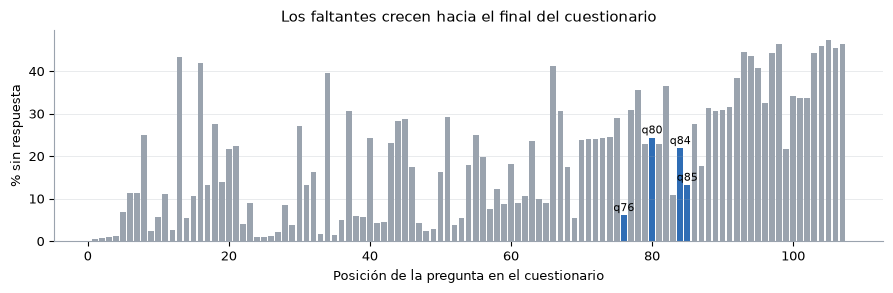

In [9]:
def analizar_patron_faltantes(datos, variable, grupo):
    '''
    Mide si los faltantes de una variable se reparten al azar.

    1. Correlación de rangos (Spearman) entre la posición de cada pregunta q1..q107 en el
       cuestionario y su porcentaje de nulos.
    2. Porcentaje de nulos de `variable` dentro de cada categoría de `grupo`.

    Retorna
    -------
    tuple(pd.Series, float, pd.Series)
        % de nulos por pregunta, correlación de rangos, % de nulos de `variable` por grupo.
    '''
    preguntas = [f"q{i}" for i in range(1, 108)]
    pct = datos[preguntas].isna().mean().mul(100)
    posicion = pd.Series(range(1, 108), index=preguntas, dtype="float64")
    rho = posicion.rank().corr(pct.rank())                 # Spearman = Pearson sobre rangos
    por_grupo = datos.groupby(grupo)[variable].apply(lambda s: s.isna().mean() * 100).round(1)
    return pct, rho, por_grupo


pct_por_pregunta, rho, nulos_q84_por_edad = analizar_patron_faltantes(df, "q84", "q1")
print(f"Correlación de rangos posición-faltantes (q1..q107): {rho:.3f}")
print("\n% de nulos en q84 (salud mental) por edad:")
print(nulos_q84_por_edad.rename(index=lambda c: ETIQUETAS["q1"][int(c)]).to_string())

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(1, 108), pct_por_pregunta.to_numpy(), color=GRIS, width=0.8)
for q in ["q76", "q80", "q84", "q85"]:
    i = int(q[1:])
    ax.bar(i, pct_por_pregunta[q], color=AZUL, width=0.8)
    ax.annotate(q, (i, pct_por_pregunta[q]), textcoords="offset points", xytext=(0, 3),
                ha="center", fontsize=8)
ax.set_xlabel("Posición de la pregunta en el cuestionario")
ax.set_ylabel("% sin respuesta")
ax.set_title("Los faltantes crecen hacia el final del cuestionario")
ax.grid(axis="y", color=GRIS, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

> **Lectura.** La correlación positiva y alta entre posición y faltantes indica **fatiga o falta
> de tiempo**: los estudiantes dejan de responder hacia el final, y `q80`, `q84` y `q85` están en
> el último tercio. Además, la falta de respuesta en `q84` cambia con la edad (es mayor en los más
> jóvenes). Los faltantes **no son completamente aleatorios**, y eso condiciona la decisión.

### 3.2 Comparar las estrategias antes de elegir

| Método | Cuándo conviene | Qué distorsiona aquí |
| --- | --- | --- |
| **Eliminar filas** (casos completos) | Faltantes escasos y aleatorios | Pierde muestra y cambia su composición por edad |
| **Moda** | Variable categórica con faltantes escasos | Infla artificialmente la categoría más frecuente |
| **Mediana** | Variable numérica asimétrica | En un código ordinal, equivale a inventar una respuesta central |
| **Conservar el faltante** | Faltantes informativos o abundantes | Nada: los métodos de F3 trabajan con casos disponibles |

La función compara el efecto de cada estrategia sobre la **distribución** de la variable ordinal,
que es lo que importa en una escala de categorías (la desviación estándar de un código no tiene
interpretación).

In [10]:
def comparar_estrategias_faltantes(datos, columna, columnas_completas):
    '''
    Compara el efecto de cuatro estrategias de tratamiento de faltantes sobre una variable ordinal.

    Parámetros
    ----------
    datos : pd.DataFrame
    columna : str
        Variable ordinal a evaluar.
    columnas_completas : list of str
        Variables que deben estar completas para el criterio de "casos completos".

    Retorna
    -------
    pd.DataFrame
        Una fila por estrategia: n, filas perdidas, % por categoría y máxima desviación
        (en puntos porcentuales) respecto de la distribución observada.

    Lanza
    -----
    ValueError
        Si la columna no tiene faltantes (no hay nada que comparar).
    '''
    original = datos[columna]
    if original.isna().sum() == 0:
        raise ValueError(f"'{columna}' no tiene valores faltantes.")
    completos = datos[columnas_completas].notna().all(axis=1)
    estrategias = {
        "conservar faltante (referencia)": original.dropna(),
        "eliminar filas (casos completos)": original[completos],
        "moda": original.fillna(original.mode().iloc[0]),
        "mediana": original.fillna(original.median()),
    }
    referencia = estrategias["conservar faltante (referencia)"].value_counts(normalize=True)
    filas = []
    for nombre, serie in estrategias.items():
        dist = serie.value_counts(normalize=True).reindex(referencia.index, fill_value=0)
        fila = {"estrategia": nombre, "n": len(serie), "filas_perdidas": len(datos) - len(serie)}
        fila.update({f"% cat {int(c)}": round(p * 100, 1) for c, p in dist.sort_index().items()})
        fila["max_desvio_pp"] = round((dist - referencia).abs().max() * 100, 1)
        filas.append(fila)
    return pd.DataFrame(filas)


comparacion_faltantes = comparar_estrategias_faltantes(df, "q84", VARIABLES_ANALISIS)
comparacion_faltantes

,estrategia,n,filas_perdidas,% cat 1,% cat 2,% cat 3,% cat 4,% cat 5,max_desvio_pp
0,conservar faltante (referencia),15705,4398,18.1,21.1,30.3,21.5,9.1,0.0
1,eliminar filas (casos completos),10941,9162,17.4,21.7,30.1,21.9,8.9,0.7
2,moda,20103,0,14.1,16.5,45.5,16.8,7.1,15.3
3,mediana,20103,0,14.1,16.5,45.5,16.8,7.1,15.3


In [11]:
# Costo adicional de eliminar filas: cambia la composición por edad de la muestra.
completos = df[VARIABLES_ANALISIS].notna().all(axis=1)
composicion = pd.DataFrame({
    "muestra completa %": df["q1"].value_counts(normalize=True).sort_index().mul(100).round(1),
    "solo casos completos %": df.loc[completos, "q1"].value_counts(normalize=True).sort_index().mul(100).round(1),
}).rename(index=lambda c: ETIQUETAS["q1"][int(c)])
print(f"Casos completos en las 7 variables: {int(completos.sum()):,} de {len(df):,} "
      f"({completos.mean() * 100:.1f} %) → se perderían {int((~completos).sum()):,} filas".replace(",", "."))
composicion

Casos completos en las 7 variables: 10.941 de 20.103 (54.4 %) → se perderían 9.162 filas


,muestra completa %,solo casos completos %
q1,,
≤12 años,0.2,0.1
13,0.2,0.1
14,12.8,10.1
15,27.6,25.4
16,26.0,26.3
17,22.3,24.8
≥18 años,10.8,13.2


**Cómo se lee.** `max_desvio_pp` es la columna que decide: cuánto se aleja cada estrategia de la
distribución realmente observada.

- **Eliminar filas** deja fuera casi la mitad de la muestra (45,6 %). La distribución de `q84` casi
  no cambia, pero sí la composición por edad: los estudiantes de 14 y 15 años pierden peso y los de
  17 y ≥18 lo ganan, porque los más jóvenes son los que más preguntas dejan sin responder.
- **La moda y la mediana** asignan a más de 4.000 estudiantes la respuesta *"A veces"* sin que la
  hayan dado: la categoría 3 se infla en más de diez puntos porcentuales.

**Decisión (bitácora 2.5):** en F2 **no se imputa ni se eliminan filas**. Los faltantes se
conservan como `NA` y se agrega una **bandera** que marca los casos completos, para que la Fase 3
decida con ella, variable por variable, qué casos usar en cada análisis.

In [12]:
# La bandera: cuántas de las 7 variables faltan y si el caso está completo.
columnas_analisis = [proc.COLUMNAS_ANALISIS[v] for v in VARIABLES_ANALISIS]
df_sel = df_sel.copy()
df_sel["n_faltantes_analisis"] = df_sel[columnas_analisis].isna().sum(axis=1).astype("int8")
df_sel["caso_completo"] = (df_sel["n_faltantes_analisis"] == 0).astype("int8")

print("Casos completos marcados:", int(df_sel["caso_completo"].sum()))
print(df_sel["n_faltantes_analisis"].value_counts().sort_index().rename("filas").to_string())

Casos completos marcados: 10941
n_faltantes_analisis
0    10941
1     6478
2     1397
3      661
4      577
5       44
6        5


> **Atención — ponderación.** Aunque se analicen solo casos completos en la Fase 3, los pesos
> muestrales de esos casos ya no suman lo mismo. Por eso se conservan `weight`, `stratum` y `psu`
> sin modificar: el análisis ponderado debe hacerse con el diseño completo y los casos disponibles.

## 4. Transformación

Cuatro transformaciones, en este orden:

1. **Casting** de la lectura (`q6orig`) y de los códigos (`float64` → entero *nullable* `Int64`).
2. **Verificación de dominio** antes de cualquier conversión.
3. **Orden ordinal declarado**: `Categorical` ordenado con `proc.transformar_datos`.
4. **Codificación** de las nominales (*one-hot* de raza/etnicidad, indicador de sexo) e
   **indicadores derivados** según los puntos de corte que publica el CDC.

### 4.1 Casting

**En la lectura.** Sin declarar su tipo, pandas lee `q6orig` por bloques y le asigna tipos
distintos según el bloque (números en unos, texto en otros), lo que produce un `DtypeWarning`.
`cargar_datos` la declara como `string`. La celda repite a propósito la lectura sin declarar el
tipo, captura la advertencia y muestra la mezcla de tipos que la provoca.

**En los códigos.** pandas lee los códigos como `float64` porque una columna entera con nulos no
cabe en `int64`. `Int64` (con mayúscula) es el entero *nullable*: guarda `1, 2, 3` como enteros y
el faltante como `<NA>`. La función falla si encuentra un valor no entero, porque un código `2.5`
no existe en el codebook.

In [13]:
import warnings

# Lectura del archivo sin declarar el tipo, capturando la advertencia en vez de mostrarla.
with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    sin_declarar = pd.read_csv(RUTA_RAW)["q6orig"]
for aviso in avisos:
    print(f"{aviso.category.__name__}: {str(aviso.message)[:70]}...")
print("\nSin dtype declarado, tipos presentes en q6orig:")
print(sin_declarar.dropna().map(lambda v: type(v).__name__).value_counts().to_string())
print("\nCon dtype declarado:", df_crudo["q6orig"].dtype,
      "· valores 'N N' (estatura no informada):", int((df_crudo["q6orig"] == "N N").sum()))


Sin dtype declarado, tipos presentes en q6orig:
q6orig
str      16237
float     3597

Con dtype declarado: string · valores 'N N' (estatura no informada): 341


In [14]:
def castear_codigos(datos, columnas):
    '''
    Convierte códigos float64 a entero nullable Int64, conservando los faltantes como <NA>.

    Lanza
    -----
    KeyError
        Si alguna columna no existe.
    ValueError
        Si alguna columna tiene valores no enteros (un código 2.5 no existe en el codebook).
    '''
    faltan = [c for c in columnas if c not in datos.columns]
    if faltan:
        raise KeyError(f"Columnas inexistentes: {faltan}")
    datos = datos.copy()
    for col in columnas:
        valores = datos[col].dropna()
        no_enteros = valores[valores != np.floor(valores)]
        if len(no_enteros):
            raise ValueError(f"'{col}' tiene {len(no_enteros)} valores no enteros, p. ej. {no_enteros.iloc[0]}")
        datos[col] = datos[col].astype("Int64")
    return datos


tipos_antes = df_sel[columnas_analisis].dtypes.astype(str)
df_t = castear_codigos(df_sel, columnas_analisis)
pd.DataFrame({"antes": tipos_antes, "después": df_t[columnas_analisis].dtypes.astype(str),
              "nulos": df_t[columnas_analisis].isna().sum()})

,antes,después,nulos
edad_cod,float64,Int64,98
sexo_cod,float64,Int64,158
raceeth_cod,float64,Int64,370
actividad_fisica_cod,float64,Int64,1227
redes_sociales_cod,float64,Int64,4900
salud_mental_cod,float64,Int64,4398
sueno_cod,float64,Int64,2662


### 4.2 Verificación de dominio

`proc.verificar_dominios` busca códigos que no existen en el codebook **antes** de convertir a
`Categorical`. El orden importa: al convertir, un código no declarado se transforma en `NaN` sin
avisar y se confunde con un faltante real.

In [15]:
errores_dominio = proc.verificar_dominios(df_t)
fuera_de_dominio = {col: e for col, e in errores_dominio.items() if e}
assert not fuera_de_dominio, f"Códigos fuera del codebook: {fuera_de_dominio}"
print(f"[OK] Las {len(errores_dominio)} variables codificadas solo contienen códigos del codebook")

[OK] Las 7 variables codificadas solo contienen códigos del codebook


### 4.3 Orden ordinal declarado

Las escalas de `q84`, `q80`, `q85`, `q76` y `q1` tienen un orden con sentido (bitácora 2.4). Se
convierten a `Categorical(ordered=True)` con el orden **declarado** en `ESCALAS_ORDINALES`. La celda
siguiente muestra por qué no se debe dejar que la herramienta deduzca el orden: si las categorías se
codificaran a partir de su texto, el orden sería **alfabético**.

In [16]:
# Opción A — deducir el orden desde el texto: pandas (como LabelEncoder) ordena alfabéticamente.
etiquetas_q84 = list(ETIQUETAS["q84"].values())
alfabetico = pd.Categorical(etiquetas_q84)                       # sin orden declarado
# Opción B — orden declarado explícitamente.
declarado = pd.Categorical(etiquetas_q84, categories=etiquetas_q84, ordered=True)

pd.DataFrame({"categoría": etiquetas_q84,
              "A · alfabético": alfabetico.codes,
              "B · declarado": declarado.codes})

,categoría,A · alfabético,B · declarado
0,Nunca,2,0
1,Rara vez,3,1
2,A veces,0,2
3,La mayor parte del tiempo,1,3
4,Siempre,4,4


Mire la columna **A**: *"Nunca"* queda con el código 2, por encima de *"A veces"* (0) y de *"La
mayor parte del tiempo"* (1). La escala quedaría desordenada y **ningún error se lanza**. Los
códigos del CDC ya vienen en el orden correcto (1 = Nunca … 5 = Siempre), y `transformar_datos` los
declara explícitamente.

In [17]:
df_t = proc.transformar_datos(df_t)

ordinales = list(proc.ESCALAS_ORDINALES)
resumen_orden = pd.DataFrame({
    "dtype": [str(df_t[c].dtype) for c in ordinales],
    "ordenada": [df_t[c].cat.ordered for c in ordinales],
    "categorías": [list(df_t[c].cat.categories) for c in ordinales],
    "nulos": [int(df_t[c].isna().sum()) for c in ordinales],
}, index=ordinales)

# La conversión no puede haber creado ni borrado faltantes.
assert (resumen_orden["nulos"] == df_sel[ordinales].isna().sum()).all(), "La conversión alteró los nulos"
resumen_orden

,dtype,ordenada,categorías,nulos
edad_cod,category,True,"[1, 2, 3, 4, 5, 6, 7]",98
redes_sociales_cod,category,True,"[1, 2, 3, 4, 5, 6, 7, 8]",4900
salud_mental_cod,category,True,"[1, 2, 3, 4, 5]",4398
sueno_cod,category,True,"[1, 2, 3, 4, 5, 6, 7]",2662
actividad_fisica_cod,category,True,"[1, 2, 3, 4, 5, 6, 7, 8]",1227


### 4.4 Codificación de las nominales

`raceeth` tiene 8 categorías **sin orden**. Dejarla como `1…8` haría creer a un modelo que
"Hispano" (6) vale más que "Asiático" (2). Se codifica con **one-hot**: una columna 0/1 por
categoría. Los nombres de las columnas salen de un diccionario declarado (código → nombre), no del
orden interno de una herramienta. La función valida antes de codificar que no aparezcan códigos no
declarados.

Los estudiantes sin respuesta en `raceeth` (1,8 %) quedan con `<NA>` en **todas** las columnas del
grupo: poner 0 en todas afirmaría que no pertenecen a ninguna categoría, lo que es un dato
inventado.

In [18]:
RAZA = {1: "raza_amerindia", 2: "raza_asiatica", 3: "raza_negra", 4: "raza_hawaiana_pacifico",
        5: "raza_blanca", 6: "raza_hispana", 7: "raza_multiple_hispana", 8: "raza_multiple_no_hispana"}


def codificar_one_hot(datos, columna, nombres):
    '''
    Codifica una variable nominal en columnas 0/1, una por categoría declarada.

    Parámetros
    ----------
    datos : pd.DataFrame
    columna : str
        Columna con códigos enteros.
    nombres : dict
        Código -> nombre de la nueva columna. Define también el orden de las columnas.

    Retorna
    -------
    pd.DataFrame
        DataFrame con las columnas nuevas (Int8, <NA> donde el original falta).
        La columna original se conserva para trazabilidad.

    Lanza
    -----
    KeyError
        Si la columna no existe.
    ValueError
        Si aparecen códigos que no están en `nombres`.
    '''
    if columna not in datos.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")
    observados = set(datos[columna].dropna().astype(int).unique())
    no_declarados = observados - set(nombres)
    if no_declarados:
        raise ValueError(f"Códigos no declarados en '{columna}': {sorted(int(c) for c in no_declarados)}")

    datos = datos.copy()
    falta = datos[columna].isna()
    for codigo, nombre in nombres.items():
        nueva = (datos[columna] == codigo).astype("Int8")
        nueva[falta] = pd.NA
        datos[nombre] = nueva
    return datos


df_t = codificar_one_hot(df_t, "raceeth_cod", RAZA)
df_t[["raceeth_cod"] + list(RAZA.values())].head()

,raceeth_cod,raza_amerindia,raza_asiatica,raza_negra,raza_hawaiana_pacifico,raza_blanca,raza_hispana,raza_multiple_hispana,raza_multiple_no_hispana
0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,5,0,0,0,0,1,0,0,0
2,5,0,0,0,0,1,0,0,0
3,5,0,0,0,0,1,0,0,0
4,5,0,0,0,0,1,0,0,0


`sexo` es binaria: una sola columna 0/1 basta (una segunda columna sería redundante). La misma
función que crea los **indicadores derivados** la construye.

### 4.5 Indicadores derivados

El CDC publica sus resultados del YRBS con puntos de corte fijos sobre estas mismas preguntas. Se
crean con esos cortes para que las cifras del proyecto puedan compararse con las publicadas. Cada
indicador vale 1 si el código está en los valores indicados, 0 si no, y `<NA>` si falta la respuesta.

| Indicador | Variable | Vale 1 cuando |
| --- | --- | --- |
| `sexo_femenino` | `q2` | 1 = Femenino |
| `salud_mental_mala` | `q84` | la mayor parte del tiempo o siempre (4–5) |
| `redes_uso_frecuente` | `q80` | varias veces al día o más (6–8) |
| `sueno_8h_o_mas` | `q85` | 8 horas o más en noche escolar (5–7) |
| `actividad_5_dias` | `q76` | activo ≥60 min al menos 5 de 7 días (6–8) |

In [19]:
def crear_indicador(datos, columna, valores_positivos, nombre):
    '''
    Crea una columna 0/1 que vale 1 si el código está en `valores_positivos`.
    Conserva <NA> donde el original falta: no convierte un faltante en 0.

    Lanza
    -----
    KeyError
        Si la columna no existe.
    ValueError
        Si `valores_positivos` está vacío.
    '''
    if columna not in datos.columns:
        raise KeyError(f"La columna '{columna}' no existe en el DataFrame.")
    if not valores_positivos:
        raise ValueError("valores_positivos no puede estar vacío.")
    datos = datos.copy()
    codigos = pd.to_numeric(datos[columna].astype("object"), errors="coerce")
    indicador = codigos.isin(valores_positivos).astype("Int8")
    indicador[codigos.isna()] = pd.NA
    datos[nombre] = indicador
    return datos


INDICADORES = [
    ("sexo_cod",             [1],       "sexo_femenino"),
    ("salud_mental_cod",     [4, 5],    "salud_mental_mala"),
    ("redes_sociales_cod",   [6, 7, 8], "redes_uso_frecuente"),
    ("sueno_cod",            [5, 6, 7], "sueno_8h_o_mas"),
    ("actividad_fisica_cod", [6, 7, 8], "actividad_5_dias"),
]
for columna, positivos, nombre in INDICADORES:
    df_t = crear_indicador(df_t, columna, positivos, nombre)

pd.DataFrame([{"indicador": n, "origen": c, "% = 1 (entre quienes responden)": round(df_t[n].mean() * 100, 1),
               "nulos": int(df_t[n].isna().sum())} for c, _, n in INDICADORES])

,indicador,origen,% = 1 (entre quienes responden),nulos
0,sexo_femenino,sexo_cod,49.6,158
1,salud_mental_mala,salud_mental_cod,30.6,4398
2,redes_uso_frecuente,redes_sociales_cod,78.1,4900
3,sueno_8h_o_mas,sueno_cod,23.0,2662
4,actividad_5_dias,actividad_fisica_cod,48.0,1227


> **Advertencia sobre estas cifras.** Son proporciones **muestrales**, sin ponderar. No deben
> compararse todavía con los porcentajes que publica el CDC, que sí están ponderados. Esa
> comparación es trabajo de la Fase 3.

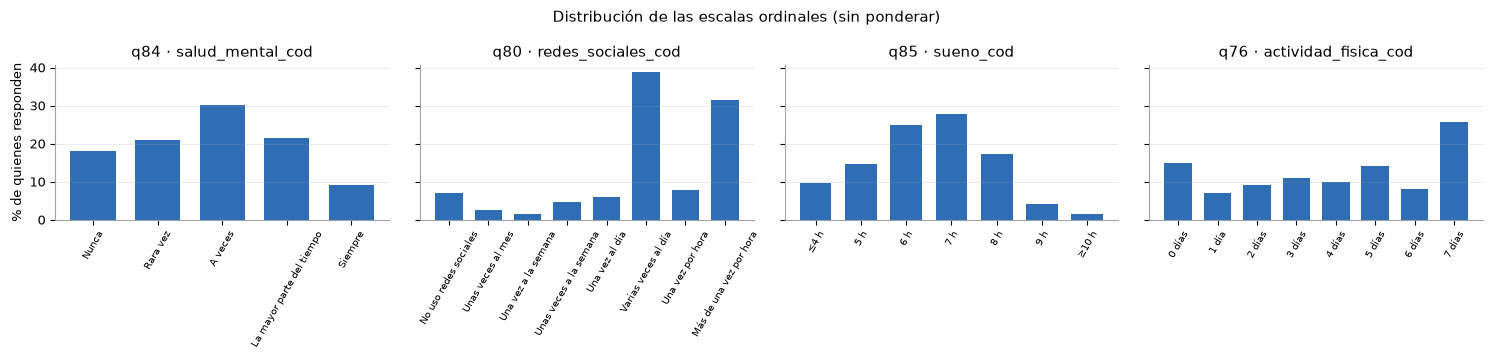

In [20]:
# Visualización de control: distribución de las cuatro escalas principales, con etiquetas del codebook.
paneles = [("q84", "salud_mental_cod"), ("q80", "redes_sociales_cod"),
           ("q85", "sueno_cod"), ("q76", "actividad_fisica_cod")]
fig, ejes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for eje, (q, col) in zip(ejes, paneles):
    pct = df_t[col].value_counts(normalize=True).sort_index().mul(100)
    eje.bar([ETIQUETAS[q][int(c)] for c in pct.index], pct.to_numpy(), color=AZUL, width=0.7)
    eje.set_title(f"{q} · {col}")
    eje.tick_params(axis="x", rotation=60, labelsize=7)
    eje.grid(axis="y", color=GRIS, alpha=0.3, linewidth=0.5)
ejes[0].set_ylabel("% de quienes responden")
plt.suptitle("Distribución de las escalas ordinales (sin ponderar)")
plt.tight_layout()
plt.show()

## 5. Escalamiento: decisión justificada de no escalar

**Qué es.** Estandarizar transforma una variable a media 0 y desviación 1: $z = (x - \mu)/\sigma$.
Sirve cuando variables continuas en escalas distintas entran juntas a un modelo basado en
distancias.

**Por qué aquí no se aplica.** En el subconjunto no hay variables continuas de análisis: las siete
son códigos ordinales o nominales, y escalar un código no tiene interpretación. La única continua es
`weight`, y un peso muestral **no puede escalarse**: su magnitud significa cuántos estudiantes
representa cada registro. La celda lo demuestra aplicando los tres escaladores a una copia.

In [21]:
def escalar(serie, metodo):
    '''
    Escala una serie numérica con el método indicado.

    standard: (x - media) / desviación · minmax: (x - mín) / (máx - mín)
    robust:   (x - mediana) / RIC

    Lanza
    -----
    ValueError
        Si el método no existe o la serie es constante.
    '''
    x = serie.astype("float64")
    if metodo == "standard":
        centro, escala = x.mean(), x.std(ddof=0)
    elif metodo == "minmax":
        centro, escala = x.min(), x.max() - x.min()
    elif metodo == "robust":
        centro, escala = x.median(), x.quantile(0.75) - x.quantile(0.25)
    else:
        raise ValueError(f"Método desconocido: {metodo}")
    if escala == 0:
        raise ValueError("La serie es constante: no se puede escalar.")
    return (x - centro) / escala


def verificar_escalamiento(valores, metodo, tol=1e-9):
    '''Comprueba que el escalamiento produjo lo que el método promete.'''
    if metodo == "standard":
        assert np.isclose(valores.mean(), 0, atol=tol) and np.isclose(valores.std(ddof=0), 1, atol=tol)
        return "media ≈ 0 y desviación ≈ 1"
    if metodo == "minmax":
        assert np.isclose(valores.min(), 0, atol=tol) and np.isclose(valores.max(), 1, atol=tol)
        return "rango [0, 1]"
    if metodo == "robust":
        ric = valores.quantile(0.75) - valores.quantile(0.25)
        assert np.isclose(valores.median(), 0, atol=1e-8) and np.isclose(ric, 1, atol=1e-8)
        return "mediana ≈ 0 y RIC ≈ 1"
    raise ValueError(f"Método desconocido: {metodo}")


pesos = df_t["peso_muestral"]
resultados = {"original": pesos}
filas = [{"escalador": "original", "negativos": int((pesos < 0).sum()), "suma": round(pesos.sum(), 1),
          "verificación": "—"}]
for metodo in ["standard", "minmax", "robust"]:
    escalado = escalar(pesos, metodo)
    resultados[metodo] = escalado
    filas.append({"escalador": metodo, "negativos": int((escalado < 0).sum()),
                  "suma": round(escalado.sum(), 1), "verificación": verificar_escalamiento(escalado, metodo)})
pd.DataFrame(filas)

,escalador,negativos,suma,verificación
0,original,0,20103.0,—
1,standard,13955,-0.0,media ≈ 0 y desviación ≈ 1
2,minmax,0,889.8,"rango [0, 1]"
3,robust,10037,9761.5,mediana ≈ 0 y RIC ≈ 1


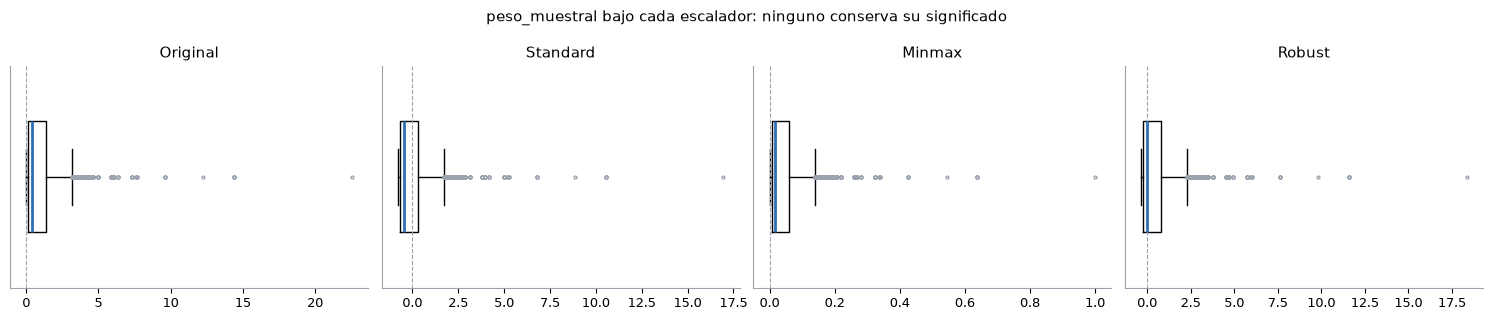

In [22]:
fig, ejes = plt.subplots(1, 4, figsize=(15, 3.2))
for eje, (nombre, valores) in zip(ejes, resultados.items()):
    eje.boxplot(valores, orientation="horizontal", widths=0.5, flierprops={"markersize": 2, "markeredgecolor": GRIS},
                medianprops={"color": AZUL, "linewidth": 2})
    eje.axvline(0, color=GRIS, linewidth=0.8, linestyle="--")
    eje.set_title(nombre.capitalize())
    eje.set_yticks([])
plt.suptitle("peso_muestral bajo cada escalador: ninguno conserva su significado")
plt.tight_layout()
plt.show()

> **Lectura.** Con `StandardScaler` o `RobustScaler` miles de pesos pasan a ser **negativos**, y un
> estudiante no puede representar a "menos de cero" estudiantes; la suma deja de ser el tamaño de la
> muestra. `MinMaxScaler` no produce negativos, pero cambia la proporción entre pesos. **Decisión:**
> no se escala ninguna columna en F2. Si en la Fase 3 un modelo necesitara escalar predictores, se
> hará dentro de ese modelo y nunca sobre `peso_muestral`.

## 6. Validación técnica y verificación del código

La función `validar_dataset` reúne las comprobaciones con `assert`: si una condición no se cumple,
el cuaderno se detiene y deja constancia de la falla.

1. **Módulo** — `proc.validar_datos` (columnas obligatorias, ID único, sin duplicados, rangos).
2. **Filas** — no se perdió ningún estudiante (20.103).
3. **Faltantes** — cada variable de análisis tiene **exactamente** los nulos que tenía al inicio:
   no se imputó ni se perdió información.
4. **Diseño muestral** — `weight`, `stratum` y `psu` están intactos.
5. **Coherencia** — el grupo *one-hot* suma 1 donde hay respuesta; cada indicador coincide con su código.

In [23]:
def validar_dataset(final, referencia, grupos_one_hot, indicadores):
    '''
    Comprueba integridad, conservación de faltantes y coherencia del dataset final.
    Lanza AssertionError si alguna comprobación falla.
    '''
    print("VALIDACIÓN DEL DATASET FINAL")
    print("-" * 50)

    resultado = proc.validar_datos(final)
    assert resultado["validacion_global"], {k: v for k, v in resultado.items() if not v}
    print(f"[OK] proc.validar_datos: {len(resultado) - 1} comprobaciones del módulo")

    assert len(final) == len(referencia) == 20103, "Cambió el número de filas."
    print(f"[OK] Filas conservadas: {len(final):,}".replace(",", "."))

    for col in columnas_analisis:
        antes, despues = int(referencia[col].isna().sum()), int(final[col].isna().sum())
        assert antes == despues, f"'{col}': {antes} nulos antes y {despues} después"
    print("[OK] Faltantes idénticos antes y después en las 7 variables (no se imputó)")

    for col in ["peso_muestral", "estrato", "psu", "id_registro"]:
        assert final[col].equals(referencia[col]), f"'{col}' fue modificada"
    print("[OK] Diseño muestral e identificador intactos")

    for nombre, (origen, cols) in grupos_one_hot.items():
        suma = final[cols].sum(axis=1, min_count=1)
        con_dato = final[origen].notna()
        assert (suma[con_dato] == 1).all(), f"'{nombre}' no suma 1 en todas las filas con dato"
        assert final.loc[~con_dato, cols].isna().all().all(), f"'{nombre}' inventa valores donde falta"
        print(f"[OK] Grupo one-hot '{nombre}': suma 1 en {int(con_dato.sum()):,} filas y <NA> en {int((~con_dato).sum())}".replace(",", "."))

    for origen, positivos, nombre in indicadores:
        codigos = pd.to_numeric(final[origen].astype("object"), errors="coerce")
        esperado = codigos.isin(positivos)
        con_dato = codigos.notna()
        assert (final.loc[con_dato, nombre].astype(bool) == esperado[con_dato]).all(), f"'{nombre}' incoherente"
        assert final.loc[~con_dato, nombre].isna().all(), f"'{nombre}' convierte faltantes en 0"
    print(f"[OK] {len(indicadores)} indicadores coherentes con su código de origen")

    print(f"[INFO] Filas duplicadas: {int(final.duplicated().sum())}")
    print(f"[INFO] Dimensiones finales: {final.shape}")
    return True


GRUPOS_ONE_HOT = {"raza/etnicidad": ("raceeth_cod", list(RAZA.values()))}
validar_dataset(df_t, df_sel, GRUPOS_ONE_HOT, INDICADORES)

VALIDACIÓN DEL DATASET FINAL
--------------------------------------------------
[OK] proc.validar_datos: 8 comprobaciones del módulo
[OK] Filas conservadas: 20.103
[OK] Faltantes idénticos antes y después en las 7 variables (no se imputó)
[OK] Diseño muestral e identificador intactos
[OK] Grupo one-hot 'raza/etnicidad': suma 1 en 19.733 filas y <NA> en 370
[OK] 5 indicadores coherentes con su código de origen
[INFO] Filas duplicadas: 0
[INFO] Dimensiones finales: (20103, 26)


True

### Pruebas de las funciones (casos normal, límite y excepciones)

Además de validar el *dataset*, se prueban las funciones nuevas de este cuaderno con datos pequeños
y conocidos, tal como pide la rúbrica.

In [24]:
prueba = pd.DataFrame({"cod": [1.0, 2.0, np.nan, 1.0]})

# --- Caso normal ---
res = codificar_one_hot(prueba, "cod", {1: "a", 2: "b"})
assert res[["a", "b"]].iloc[[0, 1, 3]].sum(axis=1).eq(1).all()
ind = crear_indicador(prueba, "cod", [2], "es_dos")
assert ind["es_dos"].tolist()[:2] == [0, 1]
assert castear_codigos(prueba, ["cod"])["cod"].dtype == "Int64"
print("[OK] Caso normal: one-hot, indicador y casting correctos")

# --- Caso límite 1: fila sin respuesta ---
assert res.loc[2, ["a", "b"]].isna().all() and pd.isna(ind.loc[2, "es_dos"])
print("[OK] Caso límite: el faltante queda <NA> en el one-hot y en el indicador, no 0")

# --- Caso límite 2: DataFrame sin filas ---
vacio = codificar_one_hot(prueba.head(0), "cod", {1: "a", 2: "b"})
assert vacio.shape == (0, 3)
print("[OK] Caso límite: DataFrame vacío conserva sus columnas")

# --- Caso límite 3: categoría declarada que no aparece ---
extra = codificar_one_hot(prueba, "cod", {1: "a", 2: "b", 3: "c"})
assert extra["c"].dropna().eq(0).all()
print("[OK] Caso límite: una categoría declarada sin observaciones queda en 0, no falla")

# --- Excepciones ---
casos_error = [
    ("código no declarado", ValueError, lambda: codificar_one_hot(prueba, "cod", {1: "a"})),
    ("columna inexistente", KeyError,   lambda: codificar_one_hot(prueba, "otra", {1: "a"})),
    ("código no entero",    ValueError, lambda: castear_codigos(pd.DataFrame({"cod": [2.5]}), ["cod"])),
    ("indicador sin valores", ValueError, lambda: crear_indicador(prueba, "cod", [], "x")),
    ("escalar constante",   ValueError, lambda: escalar(pd.Series([1.0, 1.0]), "standard")),
    ("atípicos sin datos",  ValueError, lambda: detectar_atipicos_iqr(pd.Series([np.nan]))),
]
for descripcion, tipo, llamada in casos_error:
    try:
        llamada()
        raise AssertionError(f"'{descripcion}' debió lanzar {tipo.__name__}")
    except tipo as e:
        print(f"[OK] Excepción capturada ({descripcion}): {type(e).__name__} — {str(e)[:60]}")

[OK] Caso normal: one-hot, indicador y casting correctos
[OK] Caso límite: el faltante queda <NA> en el one-hot y en el indicador, no 0
[OK] Caso límite: DataFrame vacío conserva sus columnas
[OK] Caso límite: una categoría declarada sin observaciones queda en 0, no falla
[OK] Excepción capturada (código no declarado): ValueError — Códigos no declarados en 'cod': [2]
[OK] Excepción capturada (columna inexistente): KeyError — "La columna 'otra' no existe en el DataFrame."
[OK] Excepción capturada (código no entero): ValueError — 'cod' tiene 1 valores no enteros, p. ej. 2.5
[OK] Excepción capturada (indicador sin valores): ValueError — valores_positivos no puede estar vacío.
[OK] Excepción capturada (escalar constante): ValueError — La serie es constante: no se puede escalar.
[OK] Excepción capturada (atípicos sin datos): ValueError — La serie no tiene valores numéricos para calcular cuartiles.


Vista final del *dataset* preprocesado:

In [25]:
print("Dataset final:", df_t.shape)
df_t.head()

Dataset final: (20103, 26)


,id_registro,peso_muestral,estrato,psu,edad_cod,sexo_cod,raceeth_cod,salud_mental_cod,redes_sociales_cod,sueno_cod,...,raza_hawaiana_pacifico,raza_blanca,raza_hispana,raza_multiple_hispana,raza_multiple_no_hispana,sexo_femenino,salud_mental_mala,redes_uso_frecuente,sueno_8h_o_mas,actividad_5_dias
0,1,0.8614,103,16294,3,1,<NA>,1,6,3,...,<NA>,<NA>,<NA>,<NA>,<NA>,1,0,1,0,0
1,2,0.8920,103,16294,4,2,5,3,4,5,...,0,1,0,0,0,0,0,0,1,0
2,3,0.5081,103,16294,5,2,5,2,8,1,...,0,1,0,0,0,0,0,1,0,1
3,4,1.1759,103,16294,6,1,5,3,8,4,...,0,1,0,0,0,1,0,1,0,0
4,5,0.8920,103,16294,3,2,5,3,6,3,...,0,1,0,0,0,0,0,1,0,1


---

## 7. Recursividad: aplanar los metadatos del pipeline

Todo el procesamiento anterior fue **estructurado**: secuencias, condicionales y bucles. La
recursividad es la herramienta natural cuando la estructura tiene profundidad desconocida. Los
metadatos del pipeline forman un diccionario anidado y, para exportarlos como tabla, hay que
convertirlos en pares clave-valor.

- *Caso base*: el valor no es un diccionario → se devuelve el par clave-valor.
- *Caso recursivo*: el valor es un diccionario → la función se llama a sí misma un nivel más abajo.

In [26]:
METADATOS = {
    "proyecto": {"nombre": "Redes sociales y salud mental (YRBS 2023)", "grupo": "Grupo 8",
                 "fase": "F2", "semilla": 42},
    "datos": {
        "archivo": RUTA_RAW.relative_to(RAIZ).as_posix(),
        "dimensiones_originales": list(df_crudo.shape),
        "dimensiones_finales": list(df_t.shape),
        "fuente": {"institucion": "CDC", "url": "https://www.cdc.gov/yrbs/data/index.html"},
    },
    "decisiones": {
        "eliminadas": ["orig_rec"],
        "faltantes": {"estrategia": "conservar NA + bandera caso_completo",
                      "casos_completos": int(df_t["caso_completo"].sum())},
        "ordinales": list(proc.ESCALAS_ORDINALES),
        "one_hot": {"raceeth_cod": list(RAZA.values())},
        "indicadores": {n: {"origen": c, "positivos": p} for c, p, n in INDICADORES},
        "escalamiento": "ninguno (ver sección 5)",
        "ponderacion": "no en F1-F2; weight/stratum/psu conservados",
    },
}


def aplanar(estructura, prefijo="", separador="."):
    '''
    Aplana un diccionario anidado en uno de un solo nivel.

    >>> aplanar({"a": {"b": 1, "c": {"d": 2}}})
    {'a.b': 1, 'a.c.d': 2}
    '''
    plano = {}
    for clave, valor in estructura.items():
        ruta = f"{prefijo}{separador}{clave}" if prefijo else str(clave)
        if isinstance(valor, dict):
            plano.update(aplanar(valor, ruta, separador))          # CASO RECURSIVO
        elif isinstance(valor, (list, tuple)):
            plano[ruta] = ", ".join(str(v) for v in valor)
        else:
            plano[ruta] = valor                                    # CASO BASE
    return plano


metadatos_planos = aplanar(METADATOS)
print(f"El diccionario anidado se aplanó en {len(metadatos_planos)} pares.\n")
for clave, valor in metadatos_planos.items():
    print(f"  {clave:<46} {str(valor)[:50]}")

El diccionario anidado se aplanó en 26 pares.

  proyecto.nombre                                Redes sociales y salud mental (YRBS 2023)
  proyecto.grupo                                 Grupo 8
  proyecto.fase                                  F2
  proyecto.semilla                               42
  datos.archivo                                  F1/data/raw/XXH2023_YRBSS_data.csv
  datos.dimensiones_originales                   20103, 117
  datos.dimensiones_finales                      20103, 26
  datos.fuente.institucion                       CDC
  datos.fuente.url                               https://www.cdc.gov/yrbs/data/index.html
  decisiones.eliminadas                          orig_rec
  decisiones.faltantes.estrategia                conservar NA + bandera caso_completo
  decisiones.faltantes.casos_completos           10941
  decisiones.ordinales                           edad_cod, redes_sociales_cod, salud_mental_cod, su
  decisiones.one_hot.raceeth_cod                 raza_am

In [27]:
assert aplanar({"a": 1}) == {"a": 1}, "Caso plano"
assert aplanar({"a": {"b": 1}}) == {"a.b": 1}, "Un nivel de anidamiento"
assert aplanar({"a": {"b": {"c": {"d": 4}}}}) == {"a.b.c.d": 4}, "Anidamiento profundo"
assert aplanar({}) == {}, "Caso límite: diccionario vacío"
assert aplanar({"x": [1, 2, 3]}) == {"x": "1, 2, 3"}, "Listas convertidas a texto"
print("[OK] La función recursiva pasa las cinco pruebas.")

[OK] La función recursiva pasa las cinco pruebas.


---

## 8. Persistencia y trazabilidad

El resultado se guarda con `proc.guardar_dataset` y se **relee** para comprobar que el archivo
escrito coincide con lo que está en memoria. Se exportan además el registro de decisiones (con el
esquema de cinco pasos de la bitácora) y los metadatos aplanados.

In [28]:
ruta_guardada = proc.guardar_dataset(df_t, str(RUTA_SALIDA))

# Verificación de ida y vuelta: dimensiones, columnas y valores.
releido = pd.read_csv(RUTA_SALIDA)
assert releido.shape == df_t.shape, "El archivo releído no coincide en dimensiones"
assert list(releido.columns) == list(df_t.columns), "El archivo releído no coincide en columnas"
for col in df_t.columns:
    en_memoria = pd.to_numeric(df_t[col].astype("object"), errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
    assert np.allclose(en_memoria, releido[col].to_numpy(dtype="float64"), equal_nan=True), f"'{col}' difiere"
print(f"Guardado y verificado: {Path(ruta_guardada).relative_to(RAIZ).as_posix()}")
print(f"Tamaño en disco: {Path(ruta_guardada).stat().st_size / 1024:.1f} kB")

Guardado y verificado: F2/data/processed/yrbs2023_seleccion_procesada.csv
Tamaño en disco: 1309.2 kB


In [29]:
# Registro de decisiones: dato original → problema → criterio → resultado → validación.
REGISTRO = [
    ("q6orig", "Mezcla números y texto ('N N')", "Declarar dtype string en la lectura",
     f"{int((df_crudo['q6orig'] == 'N N').sum())} valores 'N N' conservados como texto", "Sección 4.1"),
    ("orig_rec", "100 % de nulos", "Eliminar columnas sin ningún dato", "117 → 116 columnas", "assert de 100 % antes de eliminar"),
    ("117 columnas", "La mayoría no responde a la pregunta", "Selección por código (COLUMNAS_ANALISIS)",
     "116 → 11 columnas, 20.103 filas", "assert de forma (20103, 11)"),
    ("7 variables de análisis", f"{(~completos).mean() * 100:.1f} % de filas con algún faltante",
     "Faltantes no aleatorios (posición y edad): no imputar ni eliminar",
     f"NA conservados; bandera caso_completo ({int(df_t['caso_completo'].sum())} casos)", "Nulos idénticos antes y después"),
    ("Códigos float64", "Enteros guardados como decimales", "Casting a Int64 nullable", "7 columnas Int64",
     "castear_codigos lanza error ante no enteros"),
    ("Escalas ordinales", "El orden no está declarado en el tipo", "Categorical ordenado (orden del codebook)",
     "5 columnas ordinales", "Nulos idénticos tras convertir"),
    ("raceeth", "Nominal de 8 categorías codificada 1-8", "One-hot con nombres declarados",
     "8 columnas 0/1, <NA> donde falta", "Suma 1 por fila con dato"),
    ("Puntos de corte CDC", "Escalas largas difíciles de comparar", "Indicadores 0/1 con cortes del CDC",
     f"{len(INDICADORES)} indicadores", "Coherencia con el código de origen"),
    ("weight", f"{int(mascara_w.sum())} atípicos por RIC, asimetría {df_crudo['weight'].skew():.1f}",
     "Es el diseño muestral, no un error", "Sin recorte ni escalamiento", "Escaladores producen pesos negativos"),
]
registro = pd.DataFrame(REGISTRO, columns=["dato_original", "problema", "criterio", "resultado", "validacion"])
registro.to_csv(DIR_DOCS / "registro_preprocesamiento_f2.csv", index=False)

pd.DataFrame(list(metadatos_planos.items()), columns=["clave", "valor"]).to_csv(
    DIR_DOCS / "metadatos_f2.csv", index=False)
print("Exportados: docs/registro_preprocesamiento_f2.csv, docs/metadatos_f2.csv, docs/diccionario_variables_f2.csv")
registro

Exportados: docs/registro_preprocesamiento_f2.csv, docs/metadatos_f2.csv, docs/diccionario_variables_f2.csv


,dato_original,problema,criterio,resultado,validacion
0,q6orig,Mezcla números y texto ('N N'),Declarar dtype string en la lectura,341 valores 'N N' conservados como texto,Sección 4.1
1,orig_rec,100 % de nulos,Eliminar columnas sin ningún dato,117 → 116 columnas,assert de 100 % antes de eliminar
2,117 columnas,La mayoría no responde a la pregunta,Selección por código (COLUMNAS_ANALISIS),"116 → 11 columnas, 20.103 filas","assert de forma (20103, 11)"
3,7 variables de análisis,45.6 % de filas con algún faltante,Faltantes no aleatorios (posición y edad): no ...,NA conservados; bandera caso_completo (10941 c...,Nulos idénticos antes y después
4,Códigos float64,Enteros guardados como decimales,Casting a Int64 nullable,7 columnas Int64,castear_codigos lanza error ante no enteros
5,Escalas ordinales,El orden no está declarado en el tipo,Categorical ordenado (orden del codebook),5 columnas ordinales,Nulos idénticos tras convertir
6,raceeth,Nominal de 8 categorías codificada 1-8,One-hot con nombres declarados,"8 columnas 0/1, <NA> donde falta",Suma 1 por fila con dato
7,Puntos de corte CDC,Escalas largas difíciles de comparar,Indicadores 0/1 con cortes del CDC,5 indicadores,Coherencia con el código de origen
8,weight,"2330 atípicos por RIC, asimetría 2.0","Es el diseño muestral, no un error",Sin recorte ni escalamiento,Escaladores producen pesos negativos


In [30]:
# Resumen comparativo: qué cambió entre el archivo original y el dataset final.
resumen = pd.DataFrame([
    {"indicador": "Filas", "inicial": df_crudo.shape[0], "final": df_t.shape[0]},
    {"indicador": "Columnas", "inicial": df_crudo.shape[1], "final": df_t.shape[1]},
    {"indicador": "Columnas 100 % vacías", "inicial": int(df_crudo.isna().all().sum()),
     "final": int(df_t.isna().all().sum())},
    {"indicador": "Nulos en las 7 variables de análisis",
     "inicial": int(df_crudo[VARIABLES_ANALISIS].isna().sum().sum()),
     "final": int(df_t[columnas_analisis].isna().sum().sum())},
    {"indicador": "Columnas de texto", "inicial": int(df_crudo.select_dtypes(include=["object", "string"]).shape[1]),
     "final": int(df_t.select_dtypes(include=["object", "string"]).shape[1])},
    {"indicador": "Columnas con orden ordinal declarado", "inicial": 0,
     "final": int(sum(isinstance(df_t[c].dtype, pd.CategoricalDtype) for c in df_t.columns))},
    {"indicador": "Filas duplicadas", "inicial": int(df_crudo.duplicated().sum()), "final": int(df_t.duplicated().sum())},
])
resumen

,indicador,inicial,final
0,Filas,20103,20103
1,Columnas,117,26
2,Columnas 100 % vacías,1,0
3,Nulos en las 7 variables de análisis,13813,13813
4,Columnas de texto,4,0
5,Columnas con orden ordinal declarado,0,5
6,Filas duplicadas,0,0


## Conclusiones y trazabilidad

El *pipeline* redujo el archivo de 117 a 11 columnas de análisis **sin perder ningún estudiante**,
declaró el tipo y el orden de cada escala, codificó la nominal de 8 categorías, agregó 5 indicadores
con los cortes del CDC y dos columnas de control de faltantes. Los faltantes se conservaron después
de demostrar que no son aleatorios y que imputarlos o eliminarlos distorsiona la distribución y la
composición de la muestra. No se escaló ninguna columna, y la sección 5 muestra con cifras por qué.

Cada paso se implementó como función documentada: las del módulo (`cargar_datos`,
`seleccionar_columnas`, `verificar_dominios`, `transformar_datos`, `validar_datos`, `guardar_dataset`)
y las de este cuaderno (`explorar_dataframe`, `tabla_frecuencias`, `detectar_atipicos_iqr`,
`analizar_patron_faltantes`, `comparar_estrategias_faltantes`, `castear_codigos`,
`codificar_one_hot`, `crear_indicador`, `escalar`, `verificar_escalamiento`, `validar_dataset`,
`aplanar`).

**Trazabilidad con el repositorio (F2):** este cuaderno está en `F2/notebooks/`; lee el original desde
`F1/data/raw/` y escribe `F2/data/processed/yrbs2023_seleccion_procesada.csv`, que es la entrada de la
Fase 3; el diccionario, el registro de decisiones y los metadatos quedan en `docs/`.

---

## 9. Reflexión técnica

### Hallazgos

- **Los faltantes no son aleatorios.** Crecen con la posición de la pregunta en el cuestionario y
  varían con la edad. Eliminar casos incompletos habría dejado fuera casi la mitad de la muestra y
  subrepresentado a los estudiantes más jóvenes.
- **Imputar una escala ordinal inventa respuestas.** La moda y la mediana asignan *"A veces"* a
  miles de estudiantes que no respondieron `q84`, e inflan esa categoría en más de diez puntos.
- **Un peso muestral no es una variable más.** Sus más de dos mil "atípicos" son el diseño de la
  encuesta, y cualquier escalamiento produce pesos negativos.
- **El orden de una escala hay que declararlo.** Si las etiquetas de `q84` se codificaran a partir
  del texto, el orden alfabético pondría *"Nunca"* por encima de *"La mayor parte del tiempo"* sin
  lanzar ningún error.

### Dificultades y cómo se resolvieron

- **Tipo mixto en `q6orig`.** Se declaró `dtype='string'` en la lectura en vez de silenciar la advertencia.
- **Enteros con faltantes.** pandas los lee como `float64`; se resolvió con el entero *nullable* `Int64`.
- **Faltantes en el one-hot.** Poner 0 en todas las columnas de raza para quien no respondió habría
  afirmado algo falso; se dejó `<NA>` y la validación comprueba las dos situaciones.

### Decisiones que quedan abiertas

- Cómo tratar los faltantes en cada análisis de la Fase 3 (casos disponibles por variable o casos
  completos con ajuste de pesos).
- Si `q76` (días de actividad física) se analiza como ordinal o como conteo, dado que sus
  categorías sí son equidistantes.
- Qué herramienta usar para el análisis ponderado con `weight`, `stratum` y `psu`.

---

## 10. Verificación antes de entregar

**Notebook**
- Corre completo tras *Kernel → Restart Kernel and Run All Cells*, sin errores.
- La numeración de ejecución es continua.
- Cada bloque de código está precedido por una celda narrativa.
- Todas las rutas son relativas a la raíz del repositorio y la semilla está declarada.

**Contenido técnico**
- La procedencia del conjunto está documentada, con enlace y cita en APA 7.
- El diccionario declara el rol analítico de cada variable y coincide con el módulo.
- Las decisiones sobre faltantes y escalamiento están **comparadas y justificadas con cifras**.
- Hay pruebas de casos normales, límite y excepciones.

**Archivos**
- `F1/data/raw/` conserva el archivo original sin modificar.
- `F2/data/processed/` contiene el conjunto procesado.
- `docs/` contiene el diccionario, el registro de decisiones y los metadatos de F2.
- `requirements.txt` incluye `matplotlib`.

**Repositorio**
- Carpeta F2 con este notebook, commits de todos los integrantes y README actualizado.

---

*Cuaderno de la Fase 2 · Grupo 8 · MCDI500 · Magíster en Ciencia de Datos e Inteligencia
Artificial · Universidad Andrés Bello*